In [1]:
SEED = 117  #

# === Drive paths ===
DATA_2M_PATH     = "/content/drive/MyDrive/final_2M.parquet"
GOLD_TRAIN_PATH  = "/content/drive/MyDrive/gold_train.csv"
GOLD_TEST_PATH   = "/content/drive/MyDrive/gold_test.csv"

# === Output ===
OUTPUT_DIR    = "/content/drive/MyDrive/ate_phase2/output"
GATE_SAVE_DIR = f"{OUTPUT_DIR}/gate_phase2_seed{SEED}"

# === Model ===
BASE_MODEL = "roberta-base"
MAX_LENGTH = 192

# === Hyperparams ===
GATE_EPOCHS     = 3
GATE_BATCH_SIZE = 96
GATE_GRAD_ACCUM = 1
GATE_LR         = 1e-5
WARMUP_RATIO    = 0.1
WEIGHT_DECAY    = 0.01
VAL_RATIO       = 0.05

print(f"Seed: {SEED}")
print(f"Effective batch: {GATE_BATCH_SIZE * GATE_GRAD_ACCUM}")

Seed: 117
Effective batch: 96


In [2]:
!pip install -q transformers datasets accelerate

In [3]:
import os, gc, re, ast, warnings
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback,
)
from datasets import Dataset

warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


In [4]:
from google.colab import drive
drive.mount("/content/drive")

os.makedirs(GATE_SAVE_DIR, exist_ok=True)
for p in [DATA_2M_PATH, GOLD_TRAIN_PATH, GOLD_TEST_PATH]:
    assert os.path.exists(p), f"NOT FOUND: {p}"
print("All files found.")

Mounted at /content/drive
All files found.


## Step 1 — Data Preparation

In [5]:
print("Loading 2M data...")
df_2m = pd.read_parquet(DATA_2M_PATH)
gold_train = pd.read_csv(GOLD_TRAIN_PATH)
gold_test  = pd.read_csv(GOLD_TEST_PATH)
print(f"2M: {df_2m.shape}, Gold train: {gold_train.shape}, Gold test: {gold_test.shape}")

CAT_MAP = {
    "Office_Products": "office_products",
    "Electronics_part1": "electronics_p1",
    "electronics_p2": "electronics_p2",
    "Software": "software",
}
df_2m["category_name"] = df_2m["category_name"].map(CAT_MAP).fillna("kindle_store")
print(df_2m["category_name"].value_counts())

USE_COLS = ["parent_asin", "sentence_id", "sentence_text",
            "rating", "gate_confidence", "category_name"]

df_all = pd.concat([df_2m[USE_COLS], gold_train[USE_COLS]], ignore_index=True)
print(f"\nAfter merge: {len(df_all):,}")

# Remove gold_test leakage by sentence_text
test_texts = set(gold_test["sentence_text"].tolist())
before = len(df_all)
df_all = df_all[~df_all["sentence_text"].isin(test_texts)].reset_index(drop=True)
print(f"Removed {before - len(df_all)} gold_test leaks → {len(df_all):,} rows")

df_all["gate_label"] = (df_all["gate_confidence"] >= 0.5).astype(int)
print(f"\nLabel distribution:")
print(df_all["gate_label"].value_counts())

del df_2m
gc.collect()

Loading 2M data...
2M: (2000000, 8), Gold train: (3200, 8), Gold test: (800, 8)
category_name
office_products    400000
software           400000
kindle_store       400000
electronics_p2     400000
electronics_p1     400000
Name: count, dtype: int64

After merge: 2,003,200
Removed 4329 gold_test leaks → 1,998,871 rows

Label distribution:
gate_label
1    1147900
0     850971
Name: count, dtype: int64


259

In [6]:
train_idx, val_idx = train_test_split(
    np.arange(len(df_all)), test_size=VAL_RATIO,
    random_state=SEED, stratify=df_all["category_name"],
)
df_train = df_all.iloc[train_idx].reset_index(drop=True)
df_val   = df_all.iloc[val_idx].reset_index(drop=True)
print(f"Train: {len(df_train):,}  Val: {len(df_val):,}")

del df_all
gc.collect()

Train: 1,898,927  Val: 99,944


0

## Step 2 — Train Gate Classifier

In [7]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

def tokenize_gate(examples):
    return tokenizer(examples["sentence_text"],
                     truncation=True, max_length=MAX_LENGTH, padding=False)

gate_train_ds = Dataset.from_dict({
    "sentence_text": df_train["sentence_text"].tolist(),
    "label": df_train["gate_label"].tolist(),
}).map(tokenize_gate, batched=True, num_proc=2, remove_columns=["sentence_text"])

gate_val_ds = Dataset.from_dict({
    "sentence_text": df_val["sentence_text"].tolist(),
    "label": df_val["gate_label"].tolist(),
}).map(tokenize_gate, batched=True, num_proc=2, remove_columns=["sentence_text"])

print(f"Gate train: {len(gate_train_ds)}, Gate val: {len(gate_val_ds)}")

del df_train, df_val
gc.collect()

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map (num_proc=2):   0%|          | 0/1898927 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/99944 [00:00<?, ? examples/s]

Gate train: 1898927, Gate val: 99944


346

In [8]:
from transformers import DataCollatorWithPadding

def compute_gate_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":  accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall":    recall_score(labels, preds, zero_division=0),
        "f1":        f1_score(labels, preds, zero_division=0),
    }

gate_model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL, num_labels=2,
    id2label={0: "no_aspect", 1: "has_aspect"},
    label2id={"no_aspect": 0, "has_aspect": 1},
)

gate_trainer = Trainer(
    model=gate_model,
    args=TrainingArguments(
        output_dir=GATE_SAVE_DIR,
        num_train_epochs=GATE_EPOCHS,
        per_device_train_batch_size=GATE_BATCH_SIZE,
        per_device_eval_batch_size=128,
        gradient_accumulation_steps=GATE_GRAD_ACCUM,
        learning_rate=GATE_LR,
        lr_scheduler_type="linear",
        warmup_ratio=WARMUP_RATIO,
        weight_decay=WEIGHT_DECAY,
        fp16=True,
        logging_steps=200,
        eval_strategy="steps",
        eval_steps=2000,
        save_strategy="steps",
        save_steps=2000,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        save_total_limit=2,
        seed=SEED,
        dataloader_num_workers=2,
        report_to="none",
    ),
    train_dataset=gate_train_ds,
    eval_dataset=gate_val_ds,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_gate_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
)

print("Starting Gate training...")
gate_trainer.train()

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting Gate training...


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
2000,0.056007,0.033956,0.988404,0.981035,0.999074,0.989972
4000,0.045140,0.032948,0.989104,0.982512,0.998760,0.990569
6000,0.046865,0.038313,0.985962,0.977322,0.998673,0.987882
8000,0.045317,0.030583,0.990445,0.986051,0.997433,0.991709
10000,0.041296,0.027969,0.991355,0.987940,0.997084,0.992491
12000,0.039481,0.030199,0.990795,0.987304,0.996752,0.992005
14000,0.037667,0.030482,0.988984,0.982674,0.998376,0.990463
16000,0.036719,0.022236,0.992596,0.989894,0.997258,0.993563
18000,0.034051,0.026324,0.991865,0.987934,0.997992,0.992937
20000,0.030540,0.033406,0.989944,0.983865,0.998830,0.991291


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=26000, training_loss=0.05317137665015, metrics={'train_runtime': 11089.0935, 'train_samples_per_second': 513.728, 'train_steps_per_second': 5.351, 'total_flos': 1.0439795790669229e+17, 'train_loss': 0.05317137665015, 'epoch': 1.3143925989585967})

In [9]:
gate_trainer.save_model(GATE_SAVE_DIR)
tokenizer.save_pretrained(GATE_SAVE_DIR)
print(f"Gate model saved to {GATE_SAVE_DIR}")

del gate_model, gate_trainer, gate_train_ds, gate_val_ds
gc.collect()
torch.cuda.empty_cache()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Gate model saved to /content/drive/MyDrive/ate_phase2/output/gate_phase2_seed117


## Step 3 — Evaluate Gate on Gold Test

In [10]:
gate_tok   = AutoTokenizer.from_pretrained(GATE_SAVE_DIR)
gate_model = AutoModelForSequenceClassification.from_pretrained(GATE_SAVE_DIR).to(device).eval()

def parse_aspects(val):
    if isinstance(val, list): return val
    if pd.isna(val) or str(val).strip() in ("", "[]", "nan"): return []
    s = str(val).strip()
    if "," in s:
        try: return ast.literal_eval(s)
        except: pass
    m = re.findall(r"'([^']*?)'", s)
    return m if m else []

gold_test["aspects"] = gold_test["aspects"].apply(parse_aspects)
test_sentences = gold_test["sentence_text"].tolist()
test_gate_gold = gold_test["gate_confidence"].astype(int).tolist()

@torch.no_grad()
def predict_gate_probs(sentences, tokenizer, model, batch_size=64):
    probs_list = []
    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i+batch_size]
        enc = tokenizer(batch, padding=True, truncation=True,
                        max_length=MAX_LENGTH, return_tensors="pt")
        enc = {k: v.to(device) for k, v in enc.items()}
        logits = model(**enc).logits
        p = torch.softmax(logits, dim=-1)[:, 1].cpu().tolist()
        probs_list.extend(p)
    return probs_list

print("Running Gate inference on gold_test...")
test_gate_probs = predict_gate_probs(test_sentences, gate_tok, gate_model)
print(f"Done. {len(test_gate_probs)} predictions.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Running Gate inference on gold_test...
Done. 800 predictions.


In [11]:
thresholds = [round(t * 0.1, 1) for t in range(10)]
gate_results = []

for t in thresholds:
    preds = [1 if p >= t else 0 for p in test_gate_probs]
    gate_results.append({
        "threshold": t,
        "accuracy":  round(accuracy_score(test_gate_gold, preds), 4),
        "precision": round(precision_score(test_gate_gold, preds, zero_division=0), 4),
        "recall":    round(recall_score(test_gate_gold, preds, zero_division=0), 4),
        "f1":        round(f1_score(test_gate_gold, preds, zero_division=0), 4),
    })

gate_bench = pd.DataFrame(gate_results)
print("=" * 60)
print("GATE CLASSIFIER — Benchmark on Gold Test")
print("=" * 60)
print(gate_bench.to_string(index=False))

best_gate = gate_bench.loc[gate_bench["f1"].idxmax()]
print(f"\nBest threshold: {best_gate['threshold']} → F1={best_gate['f1']}")

GATE CLASSIFIER — Benchmark on Gold Test
 threshold  accuracy  precision  recall     f1
       0.0    0.5675     0.5675  1.0000 0.7241
       0.1    0.8337     0.8046  0.9339 0.8644
       0.2    0.8325     0.8065  0.9273 0.8627
       0.3    0.8350     0.8108  0.9251 0.8642
       0.4    0.8337     0.8104  0.9229 0.8630
       0.5    0.8363     0.8148  0.9207 0.8645
       0.6    0.8375     0.8164  0.9207 0.8654
       0.7    0.8413     0.8212  0.9207 0.8681
       0.8    0.8438     0.8270  0.9163 0.8694
       0.9    0.8475     0.8374  0.9075 0.8710

Best threshold: 0.9 → F1=0.871


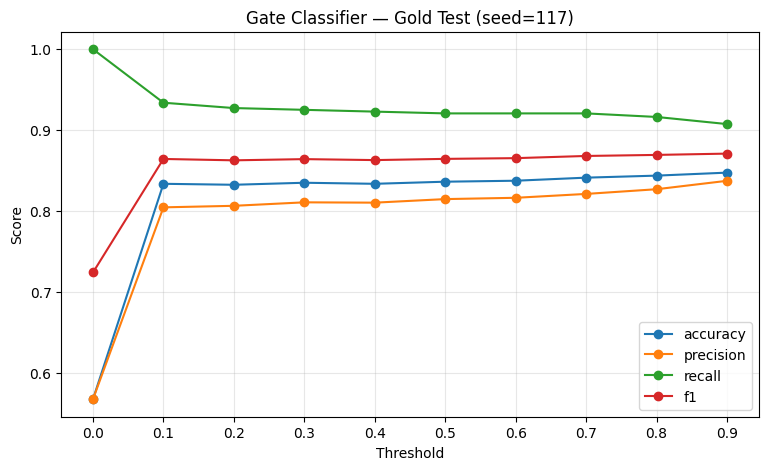

Report: /content/drive/MyDrive/ate_phase2/output/gate_benchmark_seed117.txt
Plot:   /content/drive/MyDrive/ate_phase2/output/gate_benchmark_seed117.png
Model:  /content/drive/MyDrive/ate_phase2/output/gate_phase2_seed117


In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
for metric in ["accuracy", "precision", "recall", "f1"]:
    ax.plot(gate_bench["threshold"], gate_bench[metric], marker="o", label=metric)
ax.set_title(f"Gate Classifier — Gold Test (seed={SEED})")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_xticks(thresholds)
ax.legend()
ax.grid(True, alpha=0.3)

plot_path = f"{OUTPUT_DIR}/gate_benchmark_seed{SEED}.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

report_path = f"{OUTPUT_DIR}/gate_benchmark_seed{SEED}.txt"
with open(report_path, "w") as f:
    f.write(f"GATE CLASSIFIER — Seed {SEED}\n")
    f.write("=" * 60 + "\n")
    f.write(gate_bench.to_string(index=False))
    f.write(f"\n\nBest threshold: {best_gate['threshold']} → F1={best_gate['f1']}\n")

print(f"Report: {report_path}")
print(f"Plot:   {plot_path}")
print(f"Model:  {GATE_SAVE_DIR}")